<a href="https://colab.research.google.com/github/triastrale/analisis-kausal-penyebab-pembelian-impulsif/blob/main/src/notears/NOTEARS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install matplotlib networkx pandas numpy scikit-learn notears-pytorch

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from notears_pytorch import notears_linear
from scipy.stats import zscore
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/Histori Skripsi/NOTEARS/Raw Data_Paylater and Non Paylater User_Average_Final.csv"

df = pd.read_csv(file_path, sep=";")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 13 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Gender                                                                         810 non-null    int64  
 1   E-Paylater User Status                                                         810 non-null    int64  
 2   Educational Background                                                         810 non-null    int64  
 3   Age                                                                            810 non-null    int64  
 4   Job Status                                                                     810 non-null    int64  
 5   Monthly Income                                                                 810 non-null    int64  
 6   Average monthly expenditur

,Gender,E-Paylater User Status,Educational Background,Age,Job Status,Monthly Income,Average monthly expenditure for online shopping in relation to monthly income,IBB,P,SI,H,SC,NE
0,2,1,3,27,2,3,1,2.50,3.00,1.67,3.50,3.6,3.0
1,1,2,1,22,1,2,2,1.75,3.25,2.00,4.00,3.4,4.8
2,1,1,1,22,1,2,1,3.00,3.00,3.17,4.00,4.0,3.0
3,2,2,3,22,1,1,1,4.00,4.00,4.00,4.00,3.6,1.2
4,1,2,3,22,2,6,1,1.00,2.00,1.83,3.25,3.2,2.8


In [ ]:
print("Shape data:", df.shape)
print(df.dtypes)

columns = list(df.columns)
n_vars = len(columns)

Shape data: (810, 13)
Gender                                                                             int64
E-Paylater User Status                                                             int64
Educational Background                                                             int64
Age                                                                                int64
Job Status                                                                         int64
Monthly Income                                                                     int64
Average monthly expenditure for online shopping in relation to monthly income      int64
IBB                                                                              float64
P                                                                                float64
SI                                                                               float64
H                                                                                float64

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(df.values)

In [ ]:
n_bootstrap = 1000
lambda1 = 0.05
w_threshold = 0.1
freq_threshold = 0.4
ambiguity_margin = 0.1
use_gpu=False

In [ ]:
edge_counts = np.zeros((n_vars, n_vars), dtype=int)

for b in range(n_bootstrap):
    X_boot = resample(
        X,
        replace=True,
        n_samples=X.shape[0],
        random_state=42 + b
    )

    adj_boot = notears_linear(
        X_boot,
        lambda1=lambda1,
        w_threshold=w_threshold,
        use_gpu=use_gpu
    )

    edge_counts += (adj_boot != 0).astype(int)

    if (b + 1) % 10 == 0:
        print(f"Bootstrap ke-{b+1}/{n_bootstrap} selesai")

Bootstrap ke-10/1000 selesai
Bootstrap ke-20/1000 selesai
Bootstrap ke-30/1000 selesai
Bootstrap ke-40/1000 selesai
Bootstrap ke-50/1000 selesai
Bootstrap ke-60/1000 selesai
Bootstrap ke-70/1000 selesai
Bootstrap ke-80/1000 selesai
Bootstrap ke-90/1000 selesai
Bootstrap ke-100/1000 selesai
Bootstrap ke-110/1000 selesai
Bootstrap ke-120/1000 selesai
Bootstrap ke-130/1000 selesai
Bootstrap ke-140/1000 selesai
Bootstrap ke-150/1000 selesai
Bootstrap ke-160/1000 selesai
Bootstrap ke-170/1000 selesai
Bootstrap ke-180/1000 selesai
Bootstrap ke-190/1000 selesai
Bootstrap ke-200/1000 selesai
Bootstrap ke-210/1000 selesai
Bootstrap ke-220/1000 selesai
Bootstrap ke-230/1000 selesai
Bootstrap ke-240/1000 selesai
Bootstrap ke-250/1000 selesai
Bootstrap ke-260/1000 selesai
Bootstrap ke-270/1000 selesai
Bootstrap ke-280/1000 selesai
Bootstrap ke-290/1000 selesai
Bootstrap ke-300/1000 selesai
Bootstrap ke-310/1000 selesai
Bootstrap ke-320/1000 selesai
Bootstrap ke-330/1000 selesai
Bootstrap ke-340/10

In [ ]:
edge_freq = edge_counts / n_bootstrap

results = []
for i, source in enumerate(columns):
    for j, target in enumerate(columns):
        if i != j and edge_freq[i, j] > 0:
            results.append({
                "Source": source,
                "Target": target,
                "Frequency": edge_freq[i, j],
                "Count": int(edge_counts[i, j])
            })

edges_df = pd.DataFrame(results)

if not edges_df.empty:
    edges_df = edges_df.sort_values(
        by="Frequency",
        ascending=False
    ).reset_index(drop=True)

print("Jumlah edge yang pernah muncul:", len(edges_df))
display(edges_df)

edges_df.to_csv("/content/drive/MyDrive/Histori Skripsi/NOTEARS/edges_unfiltered.csv", index=False)
edges_df.to_html("/content/drive/MyDrive/Histori Skripsi/NOTEARS/edges_unfiltered.html", index=False)
edges_df.to_excel("/content/drive/MyDrive/Histori Skripsi/NOTEARS/edges_unfiltered.xlsx", index=False)

print("Tabel berhasil disimpan:")
print("edges_unfiltered.csv")
print("edges_unfiltered.html")
print("edges_unfiltered.xlsx")

Jumlah edge yang pernah muncul: 75


,Source,Target,Frequency,Count
0,P,E-Paylater User Status,0.945,945
1,SI,P,0.941,941
2,IBB,SI,0.912,912
3,SC,IBB,0.715,715
4,Monthly Income,Educational Background,0.599,599
...,...,...,...,...
70,Average monthly expenditure for online shoppin...,SC,0.001,1
71,Average monthly expenditure for online shoppin...,Gender,0.001,1
72,Monthly Income,NE,0.001,1
73,P,Educational Background,0.001,1


Tabel berhasil disimpan:
edges_unfiltered.csv
edges_unfiltered.html
edges_unfiltered.xlsx


Kausal Graf Sebelum Filter

In [ ]:
G = nx.DiGraph()

for _, row in edges_df.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Frequency"]
    )

print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())
print("Is DAG:", nx.is_directed_acyclic_graph(G))

Jumlah node: 13
Jumlah edge: 75
Is DAG: False


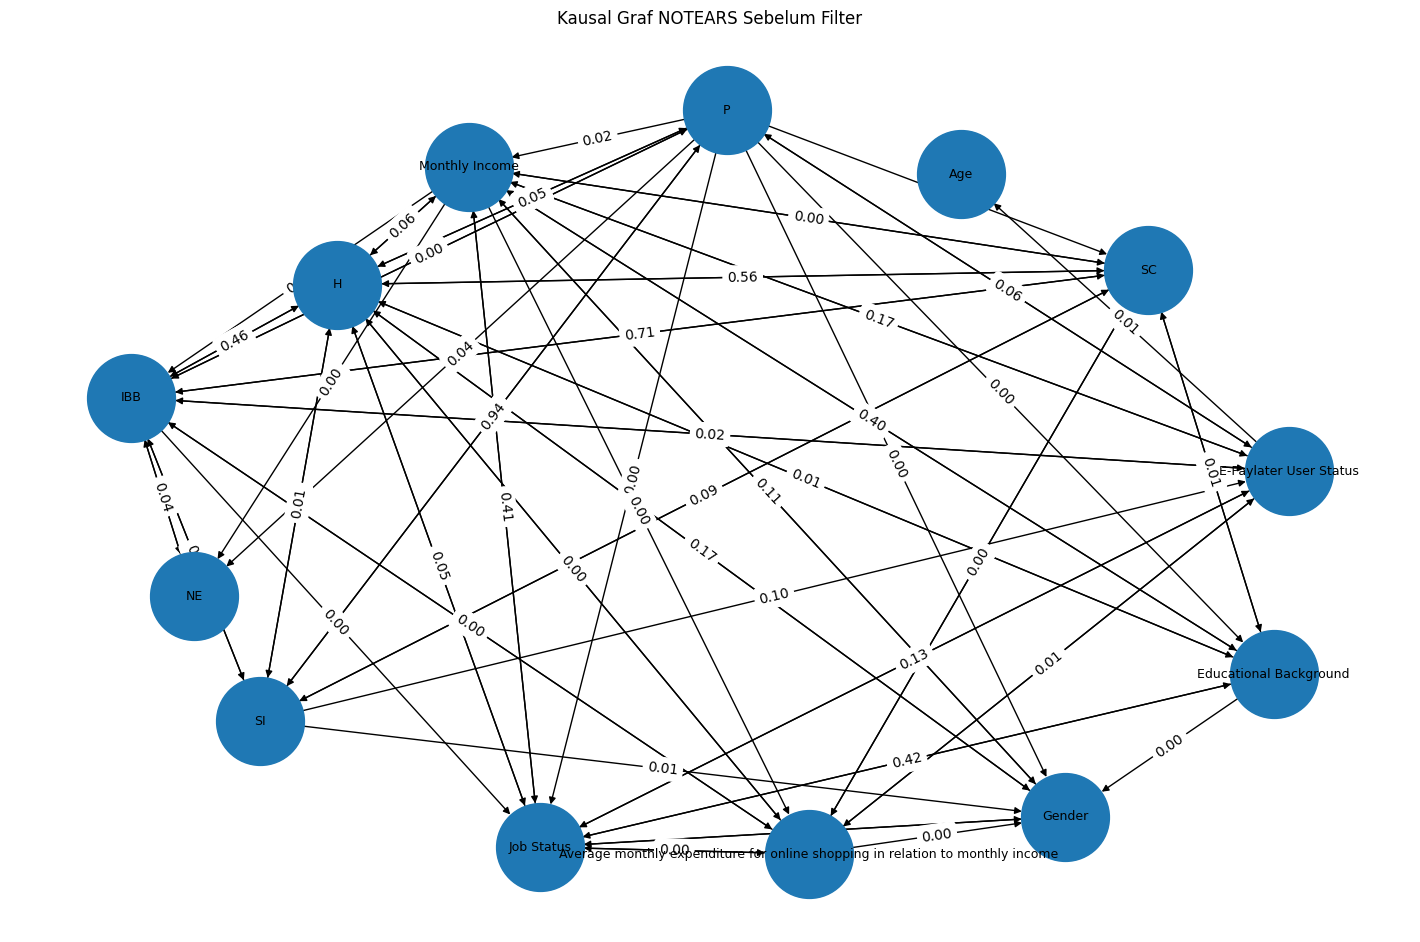

In [ ]:
plt.figure(figsize=(14, 9))

if G.number_of_edges() > 0:

    pos = nx.spring_layout(G, seed=42, k=2.2)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=4000,
        font_size=9,
        arrows=True
    )

    edge_labels = nx.get_edge_attributes(G, "weight")

    edge_labels = {
        k: f"{v:.2f}" for k, v in edge_labels.items()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=10
    )

    plt.title("Kausal Graf NOTEARS Sebelum Filter")
    plt.axis("off")
    plt.show()

else:
    print("Graph kosong.")

Kausal Graf Setelah Filter

In [ ]:
filtered = edges_df[edges_df["Frequency"] >= freq_threshold].copy()

print("Jumlah edge setelah filter frekuensi:", len(filtered))
display(filtered)

Jumlah edge setelah filter frekuensi: 16


,Source,Target,Frequency,Count
0,P,E-Paylater User Status,0.945,945
1,SI,P,0.941,941
2,IBB,SI,0.912,912
3,SC,IBB,0.715,715
4,Monthly Income,Educational Background,0.599,599
5,Monthly Income,Job Status,0.587,587
6,Educational Background,Job Status,0.581,581
7,H,SC,0.557,557
8,H,IBB,0.455,455
9,E-Paylater User Status,Average monthly expenditure for online shoppin...,0.452,452


In [ ]:
selected_edges = []
visited_pairs = set()

for _, row in filtered.iterrows():
    a = row["Source"]
    b = row["Target"]
    f_ab = row["Frequency"]

    pair_key = tuple(sorted([a, b]))
    if pair_key in visited_pairs:
        continue

    reverse = filtered[
        (filtered["Source"] == b) &
        (filtered["Target"] == a)
    ]

    if len(reverse) == 0:
        selected_edges.append((a, b, f_ab))
    else:
        f_ba = reverse.iloc[0]["Frequency"]

        if abs(f_ab - f_ba) > ambiguity_margin:
            if f_ab > f_ba:
                selected_edges.append((a, b, f_ab))
                print(
                    f"\n[EDGE DIRECTION SELECTED]\n"
                    f"Pasangan variabel : {a} dan {b}\n"
                    f"Frekuensi {a}->{b} : {f_ab:.3f}\n"
                    f"Frekuensi {b}->{a} : {f_ba:.3f}\n"
                    f"Keputusan : Memilih arah {a}->{b} "
                    f"karena frekuensinya lebih tinggi.\n"
                )
            else:
                selected_edges.append((b, a, f_ba))
                print(
                    f"\n[EDGE DIRECTION SELECTED]\n"
                    f"Pasangan variabel : {a} dan {b}\n"
                    f"Frekuensi {a}->{b} : {f_ab:.3f}\n"
                    f"Frekuensi {b}->{a} : {f_ba:.3f}\n"
                    f"Keputusan : Memilih arah {b}->{a} "
                    f"karena frekuensinya lebih tinggi.\n"
                )
        else:
            print(
                f"\n[AMBIGUOUS EDGE REMOVED]\n"
                f"Pasangan variabel : {a} dan {b}\n"
                f"Frekuensi {a}->{b} : {f_ab:.3f}\n"
                f"Frekuensi {b}->{a} : {f_ba:.3f}\n"
                f"Selisih frekuensi <= {ambiguity_margin}\n"
                f"Keputusan : Edge dibuang karena arah hubungan tidak konsisten.\n"
            )

    visited_pairs.add(pair_key)

selected_edges_df = pd.DataFrame(
    selected_edges,
    columns=["Source", "Target", "Frequency"]
)

print("\n=== EDGE FINAL UNTUK GRAPH ===")
display(selected_edges_df)


[EDGE DIRECTION SELECTED]
Pasangan variabel : Monthly Income dan Educational Background
Frekuensi Monthly Income->Educational Background : 0.599
Frekuensi Educational Background->Monthly Income : 0.401
Keputusan : Memilih arah Monthly Income->Educational Background karena frekuensinya lebih tinggi.


[EDGE DIRECTION SELECTED]
Pasangan variabel : Monthly Income dan Job Status
Frekuensi Monthly Income->Job Status : 0.587
Frekuensi Job Status->Monthly Income : 0.413
Keputusan : Memilih arah Monthly Income->Job Status karena frekuensinya lebih tinggi.


[EDGE DIRECTION SELECTED]
Pasangan variabel : Educational Background dan Job Status
Frekuensi Educational Background->Job Status : 0.581
Frekuensi Job Status->Educational Background : 0.419
Keputusan : Memilih arah Educational Background->Job Status karena frekuensinya lebih tinggi.


[AMBIGUOUS EDGE REMOVED]
Pasangan variabel : H dan IBB
Frekuensi H->IBB : 0.455
Frekuensi IBB->H : 0.443
Selisih frekuensi <= 0.1
Keputusan : Edge dibuang ka

,Source,Target,Frequency
0,P,E-Paylater User Status,0.945
1,SI,P,0.941
2,IBB,SI,0.912
3,SC,IBB,0.715
4,Monthly Income,Educational Background,0.599
5,Monthly Income,Job Status,0.587
6,Educational Background,Job Status,0.581
7,H,SC,0.557
8,E-Paylater User Status,Average monthly expenditure for online shoppin...,0.452
9,SI,SC,0.443


In [ ]:
def edges_to_dowhy_graph(edges_df):
    lines = ["digraph {"]

    for _, row in edges_df.iterrows():
        source = row["Source"]
        target = row["Target"]
        lines.append(f'    "{source}" -> "{target}";')

    lines.append("}")
    return "\n".join(lines)

dowhy_graph = edges_to_dowhy_graph(selected_edges_df)

print(dowhy_graph)

digraph {
    "P" -> "E-Paylater User Status";
    "SI" -> "P";
    "IBB" -> "SI";
    "SC" -> "IBB";
    "Monthly Income" -> "Educational Background";
    "Monthly Income" -> "Job Status";
    "Educational Background" -> "Job Status";
    "H" -> "SC";
    "E-Paylater User Status" -> "Average monthly expenditure for online shopping in relation to monthly income";
    "SI" -> "SC";
    "P" -> "H";
}


In [ ]:
G = nx.DiGraph()

for _, row in selected_edges_df.iterrows():

    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Frequency"]
    )

print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())
print("Is DAG:", nx.is_directed_acyclic_graph(G))

Jumlah node: 10
Jumlah edge: 11
Is DAG: False


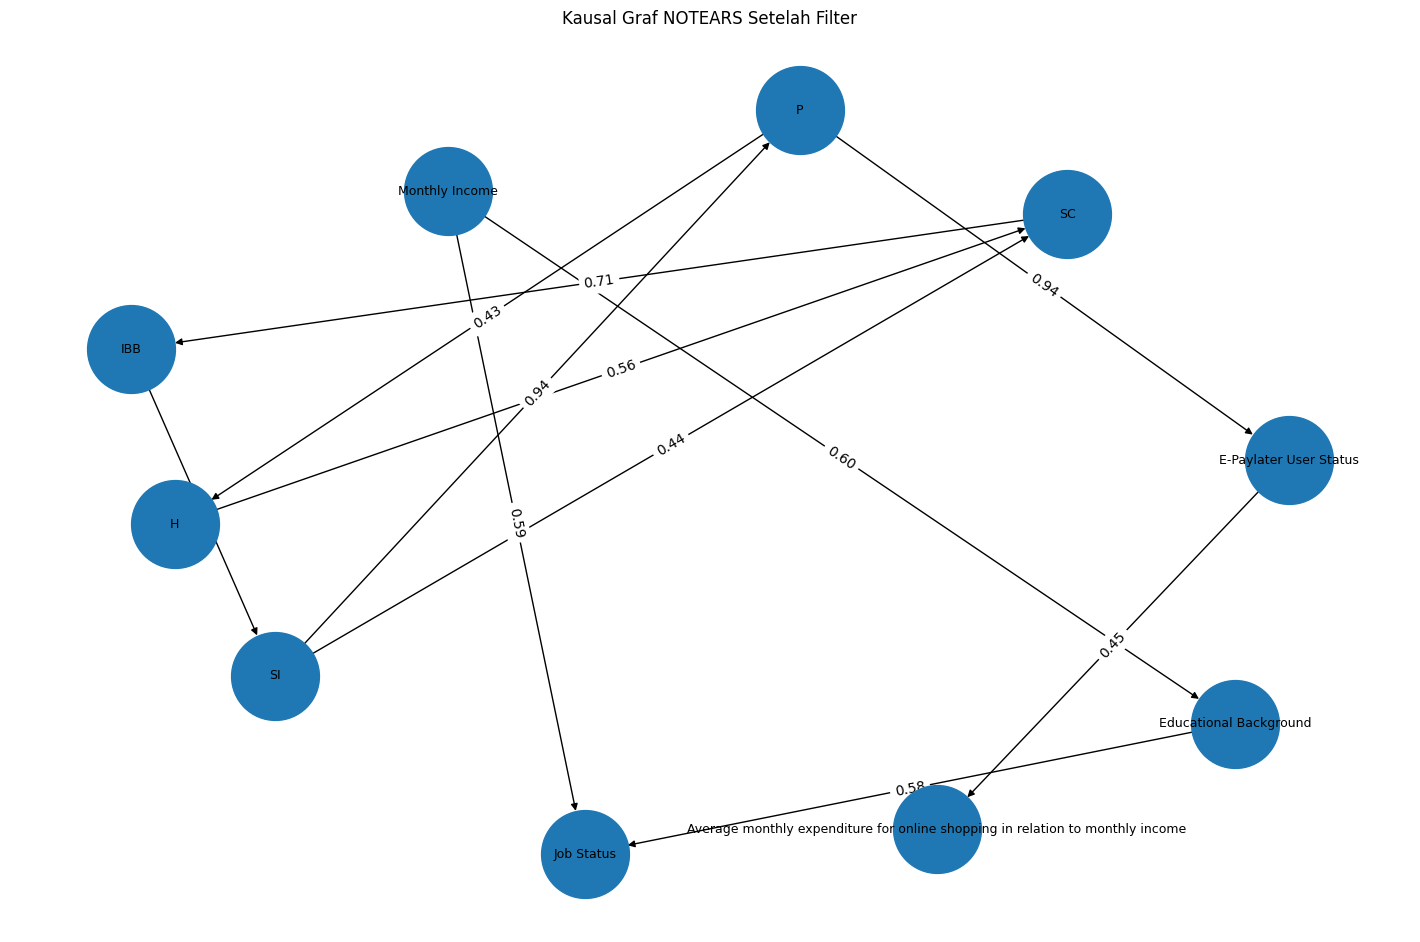

In [ ]:
plt.figure(figsize=(14, 9))

if G.number_of_edges() > 0:

    pos = nx.spring_layout(G, seed=42, k=2.2)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=4000,
        font_size=9,
        arrows=True
    )

    edge_labels = nx.get_edge_attributes(G, "weight")
    edge_labels = {
        edge: f"{freq:.2f}" for edge, freq in edge_labels.items()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=10
    )

    plt.title("Kausal Graf NOTEARS Setelah Filter")
    plt.axis("off")
    plt.show()

else:
    print("Graph kosong.")